In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
warnings.filterwarnings("ignore")

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# ── reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style
FIG_COLOR  = "#0D0D14"
ACCENT1    = "#00E5CC"
ACCENT2    = "#FF6B6B"
ACCENT3    = "#FFD166"
ACCENT4    = "#A78BFA"
GRID_COLOR = "#1E1E2E"

# 0 : LOAD SPLITS

In [2]:
BASE = "../../../data/processed/splits/"

X_train = pd.read_csv(BASE + "X_train.csv", parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv(BASE + "X_val.csv",   parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv(BASE + "X_test.csv",  parse_dates=["Date"], index_col="Date")

y_train = pd.read_csv(BASE + "y_train_reg.csv", parse_dates=["Date"], index_col="Date").squeeze()
y_val   = pd.read_csv(BASE + "y_val_reg.csv",   parse_dates=["Date"], index_col="Date").squeeze()
y_test  = pd.read_csv(BASE + "y_test_reg.csv",  parse_dates=["Date"], index_col="Date").squeeze()

# รวม train+val สำหรับ Optuna / Walk-Forward
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

print(f"  X_train    : {X_train.shape}")
print(f"  X_val      : {X_val.shape}")
print(f"  X_test     : {X_test.shape}")
print(f"  X_trainval : {X_trainval.shape}")

  X_train    : (1479, 69)
  X_val      : (501, 69)
  X_test     : (563, 69)
  X_trainval : (1980, 69)


#### HELPER — METRICS

In [3]:
def evaluate(name, y_true, y_pred):
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mae     = mean_absolute_error(y_true, y_pred)
    r2      = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    print(f"  [{name}] RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  DirAcc={dir_acc:.1f}%")
    return {"rmse": rmse, "mae": mae, "r2": r2, "dir_acc": dir_acc}


# STEP 1 : FEATURE SELECTION

In [4]:
# เทรน baseline LightGBM เร็วๆ เพื่อดู feature importance
_selector = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    max_depth=5, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

In [5]:
_selector.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [6]:
# Permutation importance บน Validation set
rng = np.random.default_rng(RANDOM_STATE)
base_rmse = np.sqrt(mean_squared_error(y_val, _selector.predict(X_val)))


In [7]:
perm_scores = {}
for col in X_train.columns:
    X_permuted = X_val.copy()
    X_permuted[col] = rng.permutation(X_permuted[col].values)
    perm_rmse = np.sqrt(mean_squared_error(y_val, _selector.predict(X_permuted)))
    perm_scores[col] = perm_rmse - base_rmse  # บวก = สำคัญ, ลบ/ศูนย์ = ไม่สำคัญ

perm_series = pd.Series(perm_scores).sort_values(ascending=False)


In [8]:
# [FIX]: เลือกเฉพาะ features ที่ช่วยจริง (importance > 0) ไม่มี Fallback
selected_features = perm_series[perm_series > 0.0].index.tolist()

print(f"\n  Original features : {X_train.shape[1]}")
print(f"  Selected strictly positive features : {len(selected_features)}")
print(f"  Top 10 by importance:")
print(perm_series.head(10).to_string())


  Original features : 69
  Selected strictly positive features : 5
  Top 10 by importance:
f_corr_90d_oil          0.000161
f_gold_ma_cross_5_20    0.000150
f_gold_body_pct         0.000127
f_gold_dist_ma10        0.000119
f_real_rate_chg_1m      0.000086
f_gold_close_ret        0.000000
f_month                 0.000000
f_rollover_flag         0.000000
f_is_month_end          0.000000
f_quarter               0.000000


In [9]:
# Apply feature selection
X_train_fs    = X_train[selected_features]
X_val_fs      = X_val[selected_features]
X_test_fs     = X_test[selected_features]
X_trainval_fs = X_trainval[selected_features]


# STEP 2 : HYPERPARAMETER TUNING

In [10]:
N_SPLITS = 5
N_TRIALS = 50
tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=1)


In [11]:
def lgb_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 16, 127),
        "max_depth"        : trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 100),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
        "verbose"          : -1,
    }
    cv_scores = []
    for train_idx, val_idx in tscv.split(X_trainval_fs):
        X_f_train = X_trainval_fs.iloc[train_idx]
        X_f_val   = X_trainval_fs.iloc[val_idx]
        y_f_train = y_trainval.iloc[train_idx]
        y_f_val   = y_trainval.iloc[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_f_train, y_f_train,
            eval_set=[(X_f_val, y_f_val)],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
        )
        pred = model.predict(X_f_val)
        cv_scores.append(np.sqrt(mean_squared_error(y_f_val, pred)))
    return np.mean(cv_scores)


In [12]:
def xgb_objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma"           : trial.suggest_float("gamma", 0, 5),
        "random_state"    : RANDOM_STATE,
        "n_jobs"          : -1,
        "tree_method"     : "hist",
        "verbosity"       : 0,
    }
    cv_scores = []
    for train_idx, val_idx in tscv.split(X_trainval_fs):
        X_f_train = X_trainval_fs.iloc[train_idx]
        X_f_val   = X_trainval_fs.iloc[val_idx]
        y_f_train = y_trainval.iloc[train_idx]
        y_f_val   = y_trainval.iloc[val_idx]
        model = xgb.XGBRegressor(**params)
        model.fit(X_f_train, y_f_train, eval_set=[(X_f_val, y_f_val)], verbose=False)
        pred = model.predict(X_f_val)
        cv_scores.append(np.sqrt(mean_squared_error(y_f_val, pred)))
    return np.mean(cv_scores)


In [13]:
# ── Run Optuna — LightGBM
print(f"\n  [Optuna] LightGBM — {N_TRIALS} trials ")
study_lgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_lgb_params = study_lgb.best_params.copy()
best_lgb_params.update({"random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1})
print(f"  LightGBM best CV RMSE : {study_lgb.best_value:.4f}")



  [Optuna] LightGBM — 50 trials 
  LightGBM best CV RMSE : 0.7109


In [14]:
# ── Run Optuna — XGBoost
print(f"\n  [Optuna] XGBoost — {N_TRIALS} trials ")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({"random_state": RANDOM_STATE, "n_jobs": -1, "tree_method": "hist", "verbosity": 0})
print(f"  XGBoost best CV RMSE : {study_xgb.best_value:.4f}")



  [Optuna] XGBoost — 50 trials 
  XGBoost best CV RMSE : 0.7122


In [15]:
# ── Retrain base models บน train → eval บน val
tuned_lgb = lgb.LGBMRegressor(**best_lgb_params)
tuned_lgb.fit(X_train_fs, y_train, eval_set=[(X_val_fs, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

tuned_xgb = xgb.XGBRegressor(**best_xgb_params)
tuned_xgb.fit(X_train_fs, y_train, eval_set=[(X_val_fs, y_val)], verbose=False)

cat_params = {
    "iterations": 1000, "learning_rate": 0.03, "depth": 6, "l2_leaf_reg": 3.0,
    "min_data_in_leaf": 20, "subsample": 0.8, "random_seed": RANDOM_STATE,
    "verbose": 0, "early_stopping_rounds": 50, "eval_metric": "RMSE", "task_type": "CPU"
}
tuned_cat = CatBoostRegressor(**cat_params)
tuned_cat.fit(X_train_fs, y_train, eval_set=(X_val_fs, y_val), verbose=False)


CatBoostRegressor(depth=6, early_stopping_rounds=50, eval_metric='RMSE', iterations=1000, l2_leaf_reg=3.0, learning_rate=0.03, loss_function='RMSE', min_data_in_leaf=20, random_seed=42, subsample=0.8, task_type='CPU', verbose=0)

In [16]:
print("\n  --- Tuned LightGBM ---")
m_lgb_val  = evaluate("Val ", y_val,  tuned_lgb.predict(X_val_fs))
m_lgb_test = evaluate("Test", y_test, tuned_lgb.predict(X_test_fs))

print("\n  --- Tuned XGBoost ---")
m_xgb_val  = evaluate("Val ", y_val,  tuned_xgb.predict(X_val_fs))
m_xgb_test = evaluate("Test", y_test, tuned_xgb.predict(X_test_fs))

print("\n  --- CatBoost ---")
m_cat_val  = evaluate("Val ", y_val,  tuned_cat.predict(X_val_fs))
m_cat_test = evaluate("Test", y_test, tuned_cat.predict(X_test_fs))



  --- Tuned LightGBM ---
  [Val ] RMSE=0.7615  MAE=0.5848  R²=0.0073  DirAcc=51.7%
  [Test] RMSE=0.8434  MAE=0.6587  R²=-0.0629  DirAcc=45.3%

  --- Tuned XGBoost ---
  [Val ] RMSE=0.7653  MAE=0.5891  R²=-0.0028  DirAcc=47.7%
  [Test] RMSE=0.8369  MAE=0.6534  R²=-0.0465  DirAcc=47.8%

  --- CatBoost ---
  [Val ] RMSE=0.7637  MAE=0.5871  R²=0.0015  DirAcc=49.9%
  [Test] RMSE=0.8400  MAE=0.6534  R²=-0.0544  DirAcc=46.2%


# STEP 3 : WEIGHTED AVERAGE ENSEMBLE 

In [17]:
def rmse_weights(*rmse_values):
    inv   = [1.0 / r for r in rmse_values]
    total = sum(inv)
    return [w / total for w in inv]


In [18]:
w_lgb, w_xgb, w_cat = rmse_weights(m_lgb_val["rmse"], m_xgb_val["rmse"], m_cat_val["rmse"])

In [19]:
print(f"\n  Ensemble weights (Inverse RMSE on Val):")
print(f"    LightGBM : {w_lgb:.4f}")
print(f"    XGBoost  : {w_xgb:.4f}")
print(f"    CatBoost : {w_cat:.4f}")



  Ensemble weights (Inverse RMSE on Val):
    LightGBM : 0.3342
    XGBoost  : 0.3325
    CatBoost : 0.3332


In [20]:
pred_lgb_val  = tuned_lgb.predict(X_val_fs)
pred_xgb_val  = tuned_xgb.predict(X_val_fs)
pred_cat_val  = tuned_cat.predict(X_val_fs)


In [21]:
pred_lgb_test = tuned_lgb.predict(X_test_fs)
pred_xgb_test = tuned_xgb.predict(X_test_fs)
pred_cat_test = tuned_cat.predict(X_test_fs)


In [22]:
pred_ens_val  = w_lgb*pred_lgb_val + w_xgb*pred_xgb_val + w_cat*pred_cat_val
pred_ens_test = w_lgb*pred_lgb_test + w_xgb*pred_xgb_test + w_cat*pred_cat_test


In [23]:
print("\n  --- Weighted-Avg Ensemble (Val) ---")
m_ens_val  = evaluate("Val ", y_val,  pred_ens_val)
print("\n  --- Weighted-Avg Ensemble (Test) ---")
m_ens_test = evaluate("Test", y_test, pred_ens_test)



  --- Weighted-Avg Ensemble (Val) ---
  [Val ] RMSE=0.7627  MAE=0.5860  R²=0.0039  DirAcc=50.1%

  --- Weighted-Avg Ensemble (Test) ---
  [Test] RMSE=0.8395  MAE=0.6539  R²=-0.0531  DirAcc=47.6%


In [24]:
best_ens_name      = "WeightedAvg Ens"
best_pred_val_ens  = pred_ens_val
best_pred_test_ens = pred_ens_test
m_best_val         = m_ens_val
m_best_test        = m_ens_test


In [25]:
# ── Comparison table
comp_ensemble = pd.DataFrame({
    "Model"      : ["LightGBM", "XGBoost", "CatBoost", "WeightedAvg Ens"],
    "Val RMSE"   : [m_lgb_val["rmse"],   m_xgb_val["rmse"],   m_cat_val["rmse"],   m_ens_val["rmse"]],
    "Val DirAcc%": [m_lgb_val["dir_acc"],m_xgb_val["dir_acc"],m_cat_val["dir_acc"],m_ens_val["dir_acc"]],
    "Test RMSE"  : [m_lgb_test["rmse"],  m_xgb_test["rmse"],  m_cat_test["rmse"],  m_ens_test["rmse"]],
    "Test DirAcc%":[m_lgb_test["dir_acc"],m_xgb_test["dir_acc"],m_cat_test["dir_acc"],m_ens_test["dir_acc"]],
    "Test R²"    : [m_lgb_test["r2"],    m_xgb_test["r2"],    m_cat_test["r2"],    m_ens_test["r2"]],
})
print("\n  Ensemble Comparison:")
print(comp_ensemble.to_string(index=False))



  Ensemble Comparison:
          Model  Val RMSE  Val DirAcc%  Test RMSE  Test DirAcc%   Test R²
       LightGBM  0.761450    51.696607   0.843397     45.293073 -0.062911
        XGBoost  0.765311    47.704591   0.836868     47.779751 -0.046518
       CatBoost  0.763671    49.900200   0.840021     46.181172 -0.054419
WeightedAvg Ens  0.762733    50.099800   0.839477     47.602131 -0.053053


# STEP 4 : WALK-FORWARD VALIDATION

In [26]:
WF_INIT_TRAIN_ROWS = len(X_train)
WF_STEP            = 63   # ~1 quarter
X_wf = pd.concat([X_train_fs, X_val_fs, X_test_fs])
y_wf = pd.concat([y_train, y_val, y_test])


In [27]:
wf_params = best_lgb_params.copy()

In [28]:
wf_predictions  = []
wf_actuals      = []
wf_dates        = []
wf_fold_metrics = []


In [29]:
start_test = WF_INIT_TRAIN_ROWS
n_total    = len(X_wf)
fold       = 0

In [30]:
print(f"\n  Walk-forward config:")
print(f"    Initial train size : {WF_INIT_TRAIN_ROWS} rows")
print(f"    Step size          : {WF_STEP} rows")
print(f"    Total rows         : {n_total}")
print(f"    Using Optuna params: ")



  Walk-forward config:
    Initial train size : 1479 rows
    Step size          : 63 rows
    Total rows         : 2543
    Using Optuna params: 


In [31]:
while start_test < n_total:
    end_test    = min(start_test + WF_STEP, n_total)
    X_wf_train  = X_wf.iloc[:start_test]
    y_wf_train  = y_wf.iloc[:start_test]
    X_wf_chunk  = X_wf.iloc[start_test:end_test]
    y_wf_chunk  = y_wf.iloc[start_test:end_test]

    wf_model = lgb.LGBMRegressor(**wf_params)
    wf_model.fit(X_wf_train, y_wf_train, callbacks=[lgb.log_evaluation(-1)])

    chunk_pred = wf_model.predict(X_wf_chunk)
    chunk_rmse = np.sqrt(mean_squared_error(y_wf_chunk, chunk_pred))
    chunk_dir  = np.mean(np.sign(y_wf_chunk) == np.sign(chunk_pred)) * 100

    wf_predictions.extend(chunk_pred.tolist())
    wf_actuals.extend(y_wf_chunk.tolist())
    wf_dates.extend(y_wf_chunk.index.tolist())
    wf_fold_metrics.append({
        "fold"    : fold,
        "start"   : y_wf_chunk.index[0].date(),
        "end"     : y_wf_chunk.index[-1].date(),
        "n_rows"  : len(y_wf_chunk),
        "RMSE"    : chunk_rmse,
        "DirAcc%" : chunk_dir,
    })
    fold       += 1
    start_test  = end_test


In [32]:
wf_df = pd.DataFrame({
    "date"     : wf_dates,
    "actual"   : wf_actuals,
    "predicted": wf_predictions,
}).set_index("date")


In [33]:
wf_overall_rmse = np.sqrt(mean_squared_error(wf_df["actual"], wf_df["predicted"]))
wf_overall_dir  = np.mean(np.sign(wf_df["actual"]) == np.sign(wf_df["predicted"])) * 100
wf_overall_r2   = r2_score(wf_df["actual"], wf_df["predicted"])


In [34]:
print(f"\n  Walk-forward fold results:")
fold_df = pd.DataFrame(wf_fold_metrics)
print(fold_df.to_string(index=False))

print(f"\n  Walk-Forward Overall:")
print(f"    RMSE   = {wf_overall_rmse:.4f}")
print(f"    DirAcc = {wf_overall_dir:.1f}%")
print(f"    R²     = {wf_overall_r2:.4f}")


  Walk-forward fold results:
 fold      start        end  n_rows     RMSE   DirAcc%
    0 2022-01-03 2022-04-01      63 0.902980 49.206349
    1 2022-04-04 2022-07-05      63 0.812219 44.444444
    2 2022-07-06 2022-10-03      63 0.924569 50.793651
    3 2022-10-04 2023-01-03      63 0.850436 50.793651
    4 2023-01-04 2023-04-04      63 0.771162 47.619048
    5 2023-04-05 2023-07-06      63 0.771769 61.904762
    6 2023-07-07 2023-10-04      63 0.651013 61.904762
    7 2023-10-05 2024-01-04      63 0.799514 42.857143
    8 2024-01-05 2024-04-05      63 0.833575 47.619048
    9 2024-04-08 2024-07-08      63 0.883406 41.269841
   10 2024-07-09 2024-10-04      63 0.879820 42.857143
   11 2024-10-07 2025-01-06      63 0.889172 50.793651
   12 2025-01-07 2025-04-07      63 0.787700 63.492063
   13 2025-04-08 2025-07-08      63 0.920991 41.269841
   14 2025-07-09 2025-10-06      63 0.815964 58.730159
   15 2025-10-07 2026-01-06      63 0.708766 58.730159
   16 2026-01-07 2026-03-27      56

# STEP 5 : VISUALIZATION

#### Panel 1: Feature Importance (top 20)

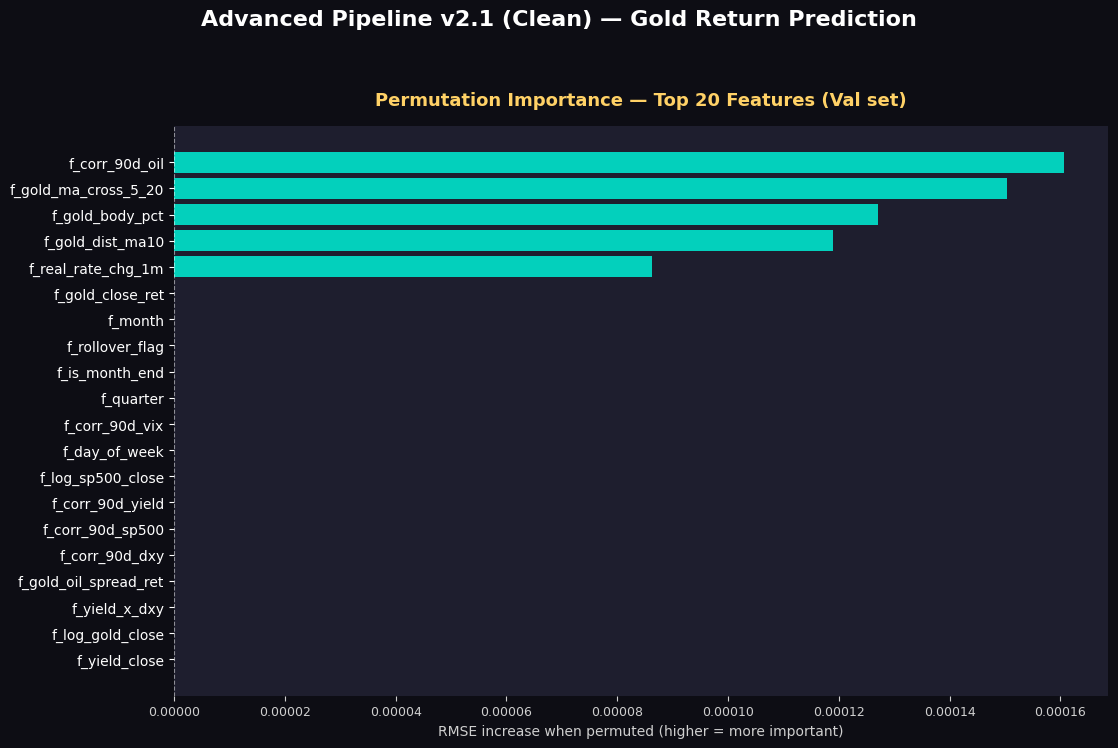

In [35]:
fig = plt.figure(figsize=(12, 8), facecolor=FIG_COLOR)

fig.suptitle("Advanced Pipeline v2.1 (Clean) — Gold Return Prediction", 
             fontsize=16, color="white", fontweight="bold", y=0.96)

gs = gridspec.GridSpec(1, 1, figure=fig) 
ax0 = fig.add_subplot(gs[0, 0])

ax0.set_facecolor(GRID_COLOR)

top_feat = perm_series.head(20)

vals = top_feat.values[::-1]
labels = top_feat.index[::-1]
colors_feat = [ACCENT1 if v > 0 else ACCENT2 for v in vals]

ax0.barh(range(len(top_feat)), vals, color=colors_feat, alpha=0.9)

ax0.set_yticks(range(len(top_feat)))
ax0.set_yticklabels(labels, fontsize=10, color="white") # เพิ่มขนาดฟอนต์

ax0.axvline(0, color="white", lw=0.8, linestyle="--", alpha=0.5)
ax0.set_title("Permutation Importance — Top 20 Features (Val set)", 
             color=ACCENT3, fontsize=13, fontweight="bold", pad=15)

ax0.set_xlabel("RMSE increase when permuted (higher = more important)", 
               color="#cfcfcf", fontsize=10)

ax0.tick_params(axis='x', colors="#cfcfcf", labelsize=9)
ax0.tick_params(axis='y', colors="white")

for spine in ax0.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.92]) 
plt.show()

#### Panel 2: Optuna History

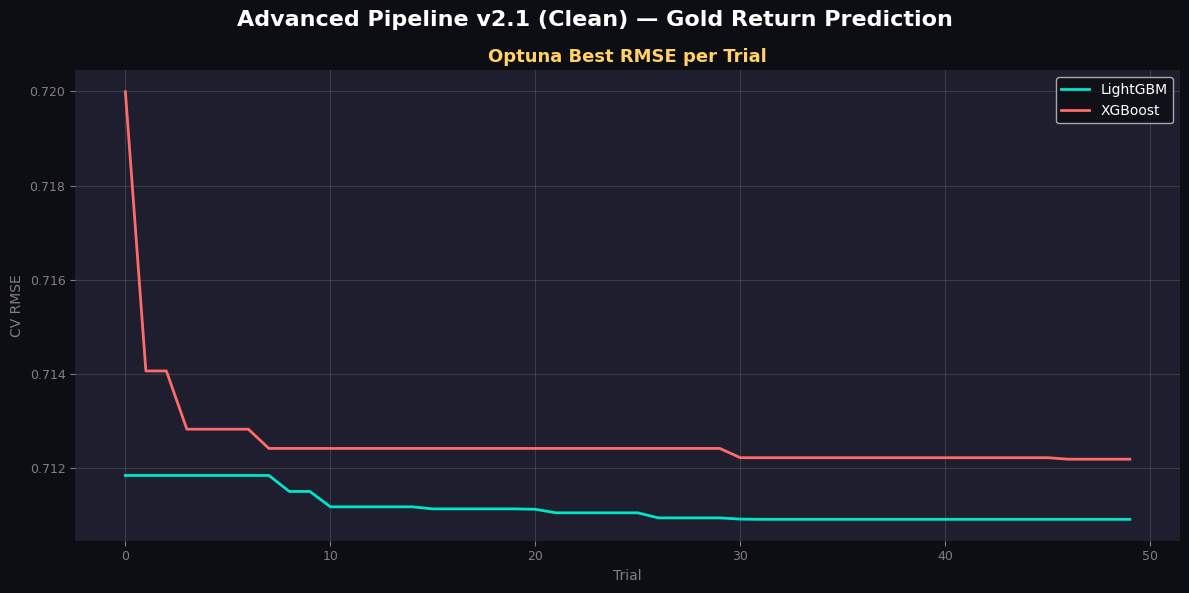

In [36]:
fig = plt.figure(figsize=(12, 6), facecolor=FIG_COLOR)

fig.suptitle(
    "Advanced Pipeline v2.1 (Clean) — Gold Return Prediction",
    fontsize=16,
    color="white",
    fontweight="bold"
)

ax1 = fig.add_subplot(111)
ax1.set_facecolor(GRID_COLOR)

# Optuna values
lgb_values = [t.value for t in study_lgb.trials]
xgb_values = [t.value for t in study_xgb.trials]

# Plot
ax1.plot(
    np.minimum.accumulate(lgb_values),
    color=ACCENT1,
    lw=2,
    label="LightGBM"
)

ax1.plot(
    np.minimum.accumulate(xgb_values),
    color=ACCENT2,
    lw=2,
    label="XGBoost"
)

# Styling
ax1.set_title(
    "Optuna Best RMSE per Trial",
    color=ACCENT3,
    fontsize=13,
    fontweight="bold"
)

ax1.set_xlabel("Trial", color="gray", fontsize=10)
ax1.set_ylabel("CV RMSE", color="gray", fontsize=10)

ax1.legend(
    fontsize=10,
    facecolor=FIG_COLOR,
    labelcolor="white"
)

ax1.tick_params(colors="gray", labelsize=9)

# Remove borders
for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.grid(alpha=0.2)

plt.tight_layout()
plt.show()

#### Panel 3: Model Comparison Bar

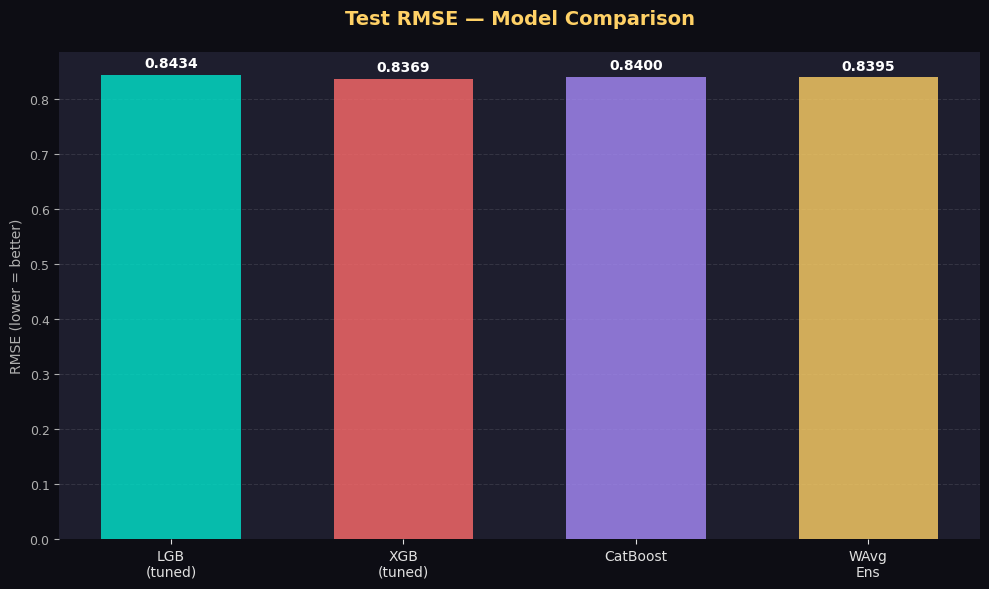

In [37]:
fig = plt.figure(figsize=(10, 6), facecolor=FIG_COLOR)

gs = gridspec.GridSpec(1, 1, figure=fig)
ax2 = fig.add_subplot(gs[0, 0])
ax2.set_facecolor(GRID_COLOR)

model_names = ["LGB\n(tuned)", "XGB\n(tuned)", "CatBoost", "WAvg\nEns"]
test_rmses = [m_lgb_test["rmse"], m_xgb_test["rmse"], m_cat_test["rmse"], m_ens_test["rmse"]]
colors_bar = [ACCENT1, ACCENT2, ACCENT4, ACCENT3]

bars = ax2.bar(model_names, test_rmses, color=colors_bar, alpha=0.8, width=0.6)

for bar, val in zip(bars, test_rmses):
    ax2.text(bar.get_x() + bar.get_width()/2, val * 1.01, f"{val:.4f}",
             ha="center", va="bottom", color="white", fontsize=10, fontweight='bold')

ax2.set_title("Test RMSE — Model Comparison", color=ACCENT3, fontsize=14, fontweight="bold", pad=20)
ax2.set_ylabel("RMSE (lower = better)", color="#b0b0b0", fontsize=10)

ax2.tick_params(axis='x', colors="#e0e0e0", labelsize=10)
ax2.tick_params(axis='y', colors="#b0b0b0", labelsize=9)

for spine in ax2.spines.values():
    spine.set_visible(False)

ax2.yaxis.grid(True, linestyle='--', alpha=0.1, color='white')
ax2.set_axisbelow(True) # ให้เส้น Grid อยู่หลัง Bar

plt.tight_layout()
plt.show()

#### Panel 4: Actual vs Predicted Test

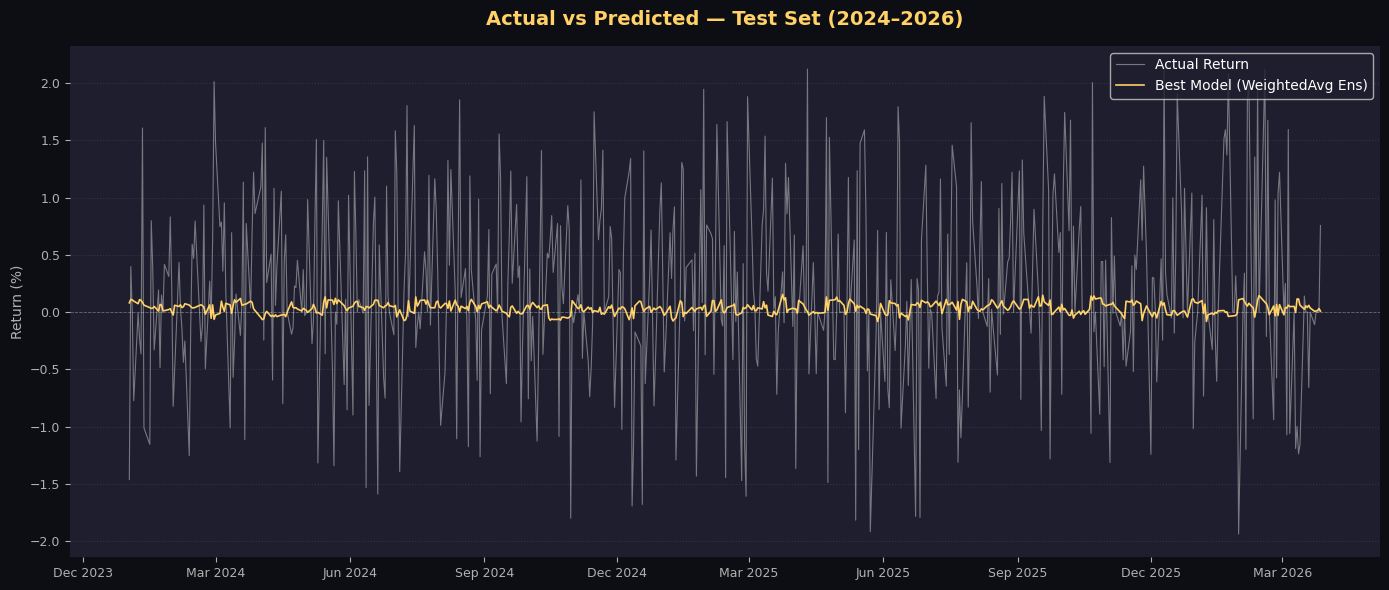

In [38]:
fig = plt.figure(figsize=(14, 6), facecolor=FIG_COLOR)

gs = gridspec.GridSpec(1, 1, figure=fig)
ax3 = fig.add_subplot(gs[0, 0])
ax3.set_facecolor(GRID_COLOR)

ax3.plot(X_test_fs.index, y_test.values, color="white", lw=0.8, alpha=0.4, label="Actual Return")
ax3.plot(X_test_fs.index, best_pred_test_ens, color=ACCENT3, lw=1.2, alpha=1.0, label=f"Best Model ({best_ens_name})")

ax3.axhline(0, color="white", linestyle="--", lw=0.6, alpha=0.3)

ax3.set_title("Actual vs Predicted — Test Set (2024–2026)", color=ACCENT3, fontsize=14, fontweight="bold", pad=15)
ax3.set_ylabel("Return (%)", color="#b0b0b0", fontsize=10)

ax3.legend(fontsize=10, facecolor=GRID_COLOR, labelcolor="white", framealpha=0.8, loc="upper right")


ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) 
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax3.tick_params(axis='x', colors="#b0b0b0", labelsize=9, rotation=0)
ax3.tick_params(axis='y', colors="#b0b0b0", labelsize=9)

for spine in ax3.spines.values():
    spine.set_visible(False)
ax3.yaxis.grid(True, linestyle=':', alpha=0.1, color='white')

plt.tight_layout()
plt.show()

#### Panel 5: Walk-Forward RMSE per fold

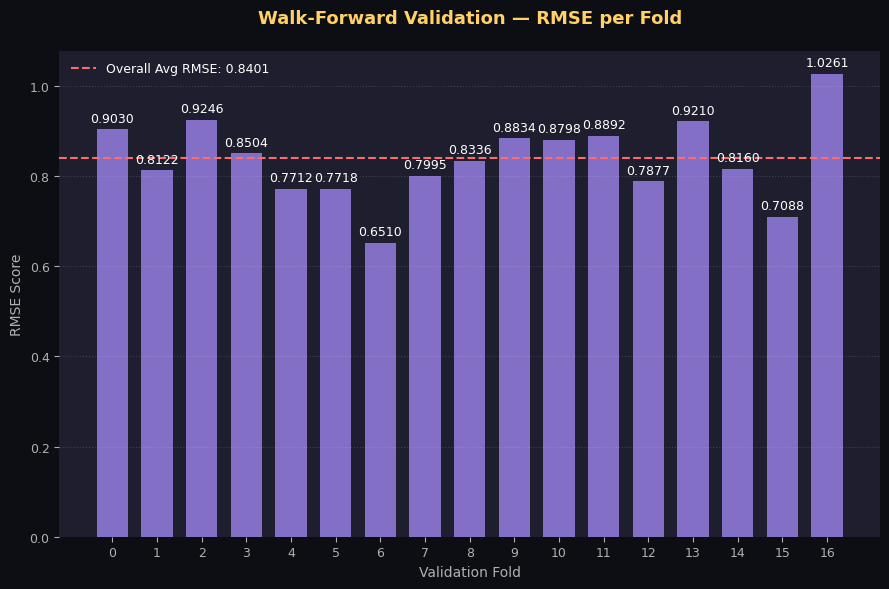

In [39]:
fig = plt.figure(figsize=(9, 6), facecolor=FIG_COLOR)

gs = gridspec.GridSpec(1, 1, figure=fig)
ax4 = fig.add_subplot(gs[0, 0])
ax4.set_facecolor(GRID_COLOR)

fold_rmses = [f["RMSE"] for f in wf_fold_metrics]
x_folds = range(len(fold_rmses))

bars = ax4.bar(x_folds, fold_rmses, color=ACCENT4, alpha=0.75, width=0.7)

for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + (max(fold_rmses)*0.01),
             f'{height:.4f}', ha='center', va='bottom', color='white', fontsize=9)

ax4.axhline(wf_overall_rmse, color=ACCENT2, linestyle="--", lw=1.5, 
            label=f"Overall Avg RMSE: {wf_overall_rmse:.4f}")

ax4.set_title("Walk-Forward Validation — RMSE per Fold", color=ACCENT3, fontsize=13, fontweight="bold", pad=20)
ax4.set_xlabel("Validation Fold", color="#b0b0b0", fontsize=10)
ax4.set_ylabel("RMSE Score", color="#b0b0b0", fontsize=10)

ax4.legend(fontsize=9, facecolor=GRID_COLOR, labelcolor="white", edgecolor="none", loc="upper left")
ax4.tick_params(colors="#b0b0b0", labelsize=9)
ax4.set_xticks(x_folds) # ให้โชว์เลข Fold ทุกอัน

for spine in ax4.spines.values():
    spine.set_visible(False)
ax4.yaxis.grid(True, linestyle=':', alpha=0.15, color='white')

plt.tight_layout()
plt.show()

#### Panel 6: Walk-Forward DirAcc per fold

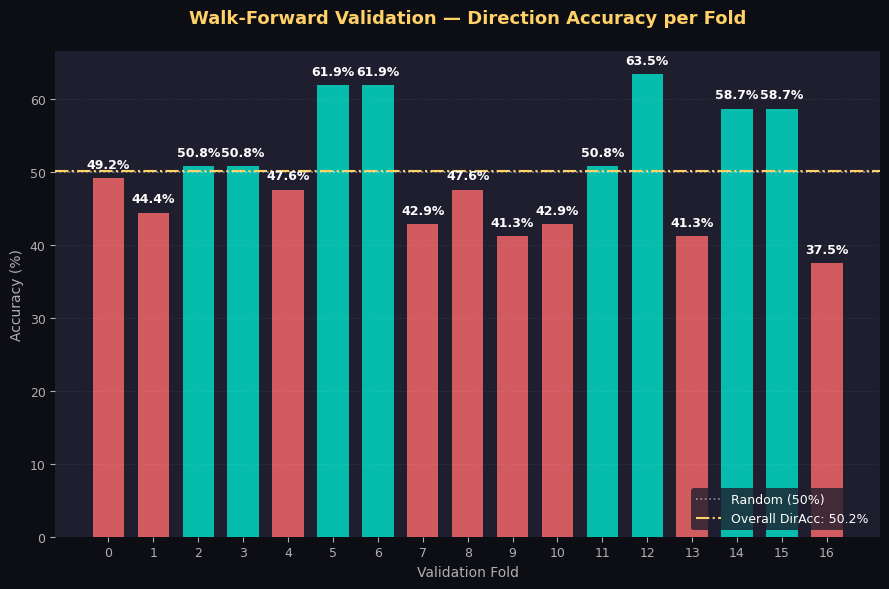

In [40]:
fig = plt.figure(figsize=(9, 6), facecolor=FIG_COLOR)

gs = gridspec.GridSpec(1, 1, figure=fig)
ax5 = fig.add_subplot(gs[0, 0])
ax5.set_facecolor(GRID_COLOR)

dir_accs = [f["DirAcc%"] for f in wf_fold_metrics]
x_folds = range(len(dir_accs))

colors_wf = [ACCENT1 if d > 50 else ACCENT2 for d in dir_accs]
bars = ax5.bar(x_folds, dir_accs, color=colors_wf, alpha=0.8, width=0.7)

for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{height:.1f}%", ha="center", va="bottom", 
             color="white", fontsize=9, fontweight="bold")

ax5.axhline(50, color="white", linestyle=":", lw=1.2, alpha=0.5, label="Random (50%)")
ax5.axhline(wf_overall_dir, color=ACCENT3, linestyle="-.", lw=1.5, 
            label=f"Overall DirAcc: {wf_overall_dir:.1f}%")

ax5.set_title("Walk-Forward Validation — Direction Accuracy per Fold", 
             color=ACCENT3, fontsize=13, fontweight="bold", pad=20)
ax5.set_ylabel("Accuracy (%)", color="#b0b0b0", fontsize=10)
ax5.set_xlabel("Validation Fold", color="#b0b0b0", fontsize=10)


ax5.legend(fontsize=9, facecolor=GRID_COLOR, labelcolor="white", edgecolor="none", loc="lower right")
ax5.tick_params(colors="#b0b0b0", labelsize=9)
ax5.set_xticks(x_folds)

for spine in ax5.spines.values():
    spine.set_visible(False)
ax5.yaxis.grid(True, linestyle=':', alpha=0.1, color='white')

plt.tight_layout()
plt.show()

#### Panel 7: Residual distribution

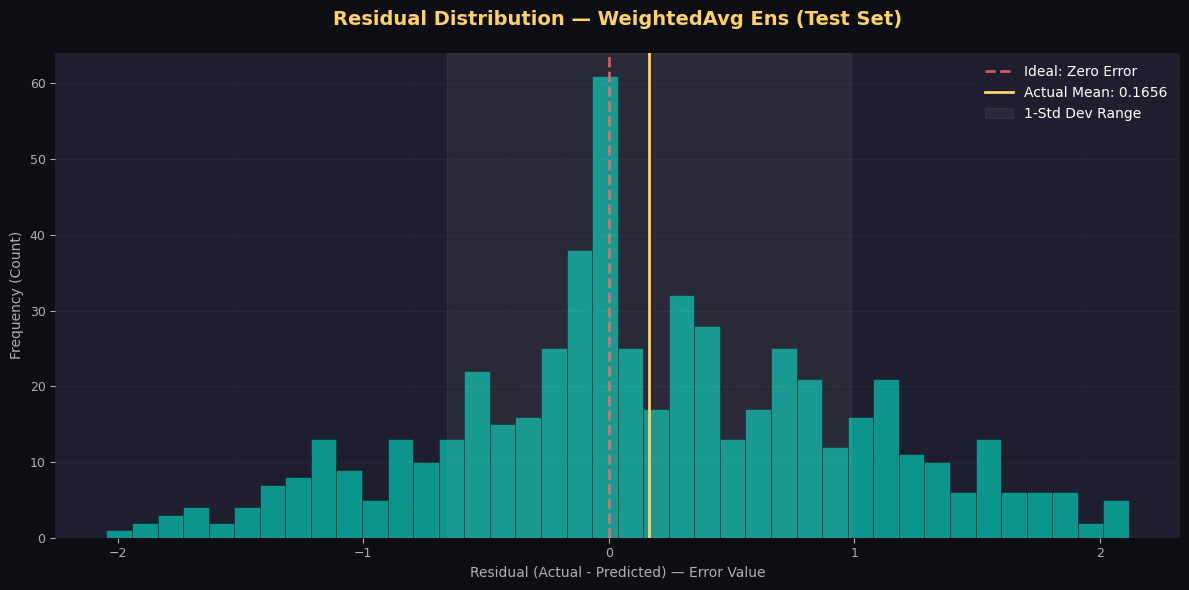

In [41]:
fig = plt.figure(figsize=(12, 6), facecolor=FIG_COLOR)

gs = gridspec.GridSpec(1, 1, figure=fig)
ax6 = fig.add_subplot(gs[0, 0])
ax6.set_facecolor(GRID_COLOR)

residuals = y_test.values - best_pred_test_ens
mean_res = np.mean(residuals)

ax6.hist(residuals, bins=40, color=ACCENT1, alpha=0.6, edgecolor=FIG_COLOR, lw=0.5)

ax6.axvline(0, color=ACCENT2, lw=2, linestyle="--", label="Ideal: Zero Error", alpha=0.8)
ax6.axvline(mean_res, color=ACCENT3, lw=2, linestyle="-", label=f"Actual Mean: {mean_res:.4f}")

std_res = np.std(residuals)
ax6.axvspan(mean_res - std_res, mean_res + std_res, color='white', alpha=0.05, label="1-Std Dev Range")

ax6.set_title(f"Residual Distribution — {best_ens_name} (Test Set)", 
             color=ACCENT3, fontsize=14, fontweight="bold", pad=20)
ax6.set_xlabel("Residual (Actual - Predicted) — Error Value", color="#b0b0b0", fontsize=10)
ax6.set_ylabel("Frequency (Count)", color="#b0b0b0", fontsize=10)

ax6.legend(fontsize=10, facecolor=GRID_COLOR, labelcolor="white", edgecolor="none", loc="upper right")

ax6.tick_params(colors="#b0b0b0", labelsize=9)
for spine in ax6.spines.values():
    spine.set_visible(False)

ax6.yaxis.grid(True, linestyle=':', alpha=0.1, color='white')

plt.tight_layout()
plt.show()

# FINAL SUMMARY

In [42]:
print(f"""
  STEP 1 — FEATURE SELECTION (Strict)
    Original features : {X_train.shape[1]:<6}
    Selected features : {len(selected_features):<6}  (Only Importance > 0)

  STEP 2 — HYPERPARAMETER TUNING (Optuna, {N_TRIALS} trials)
    LightGBM best CV RMSE: {study_lgb.best_value:.4f}
    XGBoost  best CV RMSE: {study_xgb.best_value:.4f}

  STEP 3 — WEIGHTED AVERAGE ENSEMBLE
    Test RMSE    : {m_best_test['rmse']:.4f}
    Test DirAcc  : {m_best_test['dir_acc']:.1f}%
    Test R²      : {m_best_test['r2']:.4f}

  STEP 4 — WALK-FORWARD VALIDATION (Optuna params)
    Overall RMSE : {wf_overall_rmse:.4f}
    Overall Dir  : {wf_overall_dir:.1f}%
    Overall R²   : {wf_overall_r2:.4f}
""")


  STEP 1 — FEATURE SELECTION (Strict)
    Original features : 69    
    Selected features : 5       (Only Importance > 0)

  STEP 2 — HYPERPARAMETER TUNING (Optuna, 50 trials)
    LightGBM best CV RMSE: 0.7109
    XGBoost  best CV RMSE: 0.7122

  STEP 3 — WEIGHTED AVERAGE ENSEMBLE
    Test RMSE    : 0.8395
    Test DirAcc  : 47.6%
    Test R²      : -0.0531

  STEP 4 — WALK-FORWARD VALIDATION (Optuna params)
    Overall RMSE : 0.8401
    Overall Dir  : 50.2%
    Overall R²   : -0.1076



# EXPORT REGRESSION PREDICTIONS FOR BACKTEST

In [43]:
# สร้างโฟลเดอร์สำหรับเก็บไฟล์ (ถ้ายังไม่มี)
SAVE_DIR = "../../../data/processed/predictions"
os.makedirs(SAVE_DIR, exist_ok=True)

# สร้าง DataFrame เก็บผลทำนายของ Test Set
# ใช้ X_test_fs.index เพื่อให้มีคอลัมน์ Date สำหรับไป Merge กับ Classification
reg_output_df = pd.DataFrame({
    "actual_return": y_test.values,
    "pred_return": best_pred_test_ens  # ผลทำนายจาก WeightedAvg Ensemble
}, index=X_test_fs.index)

# ตั้งชื่อ Index 
reg_output_df.index.name = "Date"

# บันทึกไฟล์ CSV
save_path = f"{SAVE_DIR}/reg_predictions_v2_clean.csv"
reg_output_df.to_csv(save_path)

print(f"  Saved Regression predictions to: {save_path}")
print(f"  Total rows: {len(reg_output_df)}")
print("\n  Sample Data (first 5 rows):")
print(reg_output_df.head().to_string())

  Saved Regression predictions to: ../../../data/processed/predictions/reg_predictions_v2_clean.csv
  Total rows: 563

  Sample Data (first 5 rows):
            actual_return  pred_return
Date                                  
2024-01-02      -1.462892     0.081149
2024-01-03       0.398196     0.111390
2024-01-04       0.004895     0.106679
2024-01-05      -0.773602     0.096283
2024-01-08      -0.009866     0.073640


In [44]:
print(best_lgb_params)

{'n_estimators': 725, 'learning_rate': 0.06617596968048838, 'num_leaves': 27, 'max_depth': 6, 'min_child_samples': 93, 'subsample': 0.9589199546789873, 'colsample_bytree': 0.657274777063807, 'reg_alpha': 0.004439653780309992, 'reg_lambda': 0.060009792539478475, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [45]:
print(selected_features)

['f_corr_90d_oil', 'f_gold_ma_cross_5_20', 'f_gold_body_pct', 'f_gold_dist_ma10', 'f_real_rate_chg_1m']
